In [47]:
from pathlib import *
import os
import random
random.seed(42)

import collections
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import json
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score


pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [35]:
with open('IDS/training_metrics/packet_stats/training_stats_final.json','r') as f:
    stats = json.load(f)

In [37]:
len(stats['train_pred'][0]), len(stats['train_pred'][-1]), len(stats['val_pred'][0]), len(stats['val_pred'][-1]) #assert 80-20 split

(1115192, 1115192, 278798, 278798)

In [52]:
bin_preds = []
bin_labels = []
for preds, labels in zip(stats['train_pred'], stats['train_labels']):
    bin_preds.append((np.array(preds) != 0).astype(int))
    bin_labels.append((np.array(labels) != 0).astype(int))

bin_vpreds = []
bin_vlabels = []
for preds, labels in zip(stats['val_pred'], stats['val_labels']):
    bin_vpreds.append((np.array(preds) != 0).astype(int))
    bin_vlabels.append((np.array(labels) != 0).astype(int))

### Raw Loss and Accuracy

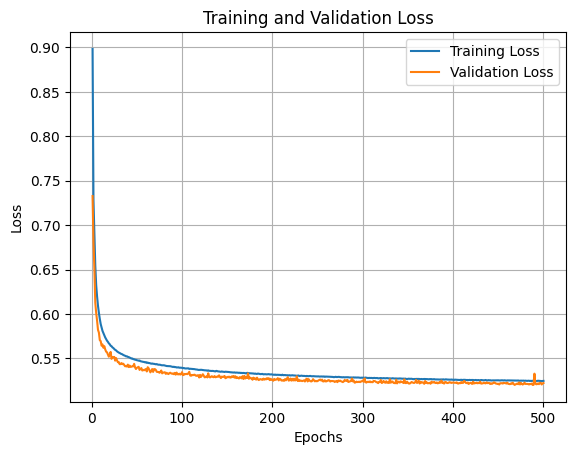

In [36]:
epochs = range(1, len(stats['train_loss']) + 1)

# Plot training loss
plt.plot(epochs, stats['train_loss'], label='Training Loss')

# Plot validation loss
plt.plot(epochs, stats['val_loss'], label='Validation Loss')

# Add labels and title
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')

# Add legend
plt.legend()

# Show plot
plt.grid(True)
plt.show()

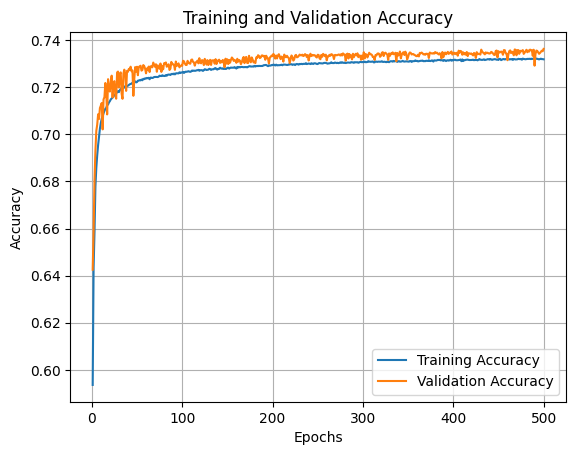

In [46]:
t_acc = []
v_acc = []
for preds, labels in zip(stats['train_pred'], stats['train_labels']):
    t_acc.append(sum(1 for pred, label in zip(preds, labels) if pred == label) / len(labels))

for preds, labels in zip(stats['val_pred'], stats['val_labels']):
    v_acc.append(sum(1 for pred, label in zip(preds, labels) if pred == label) / len(labels))

epochs = range(1, len(t_acc) + 1)

# Plot training loss
plt.plot(epochs, t_acc, label='Training Accuracy')

# Plot validation loss
plt.plot(epochs, v_acc, label='Validation Accuracy')

# Add labels and title
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')

# Add legend
plt.legend()

# Show plot
plt.grid(True)
plt.show()

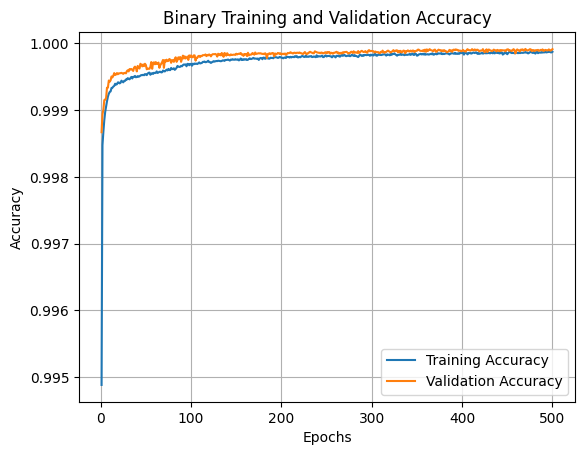

In [55]:
t_acc = []
v_acc = []
for preds, labels in zip(bin_preds, bin_labels):
    t_acc.append(sum(1 for pred, label in zip(preds, labels) if pred == label) / len(labels))

for preds, labels in zip(bin_vpreds, bin_vlabels):
    v_acc.append(sum(1 for pred, label in zip(preds, labels) if pred == label) / len(labels))

epochs = range(1, len(t_acc) + 1)

# Plot training loss
plt.plot(epochs, t_acc, label='Training Accuracy')

# Plot validation loss
plt.plot(epochs, v_acc, label='Validation Accuracy')

# Add labels and title
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Binary Training and Validation Accuracy')

# Add legend
plt.legend()

# Show plot
plt.grid(True)
plt.show()

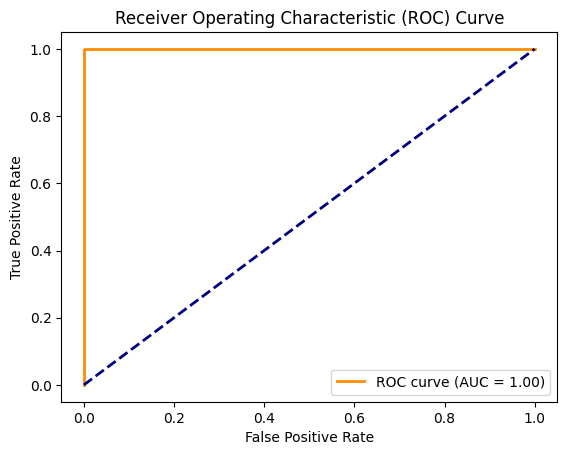

In [54]:
fpr, tpr, thresholds = roc_curve(bin_labels[-1], bin_labels[-1])

auc_score = roc_auc_score(bin_labels[-1], bin_labels[-1])

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

### Confusion Matrices

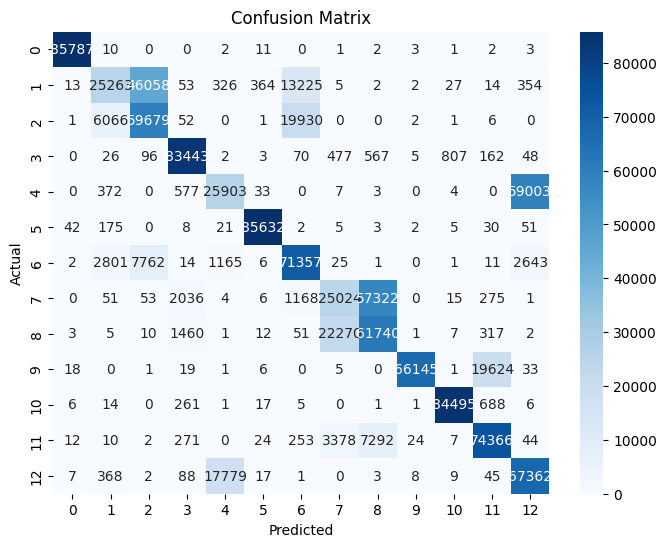

In [38]:
tconmat = confusion_matrix(stats['train_labels'][-1],stats['train_pred'][-1])
plt.figure(figsize=(8, 6))
sns.heatmap(tconmat, annot=True, cmap='Blues', fmt='d', 
            xticklabels=np.unique(stats['train_labels'][-1]), yticklabels=np.unique(stats['train_labels'][-1]))
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

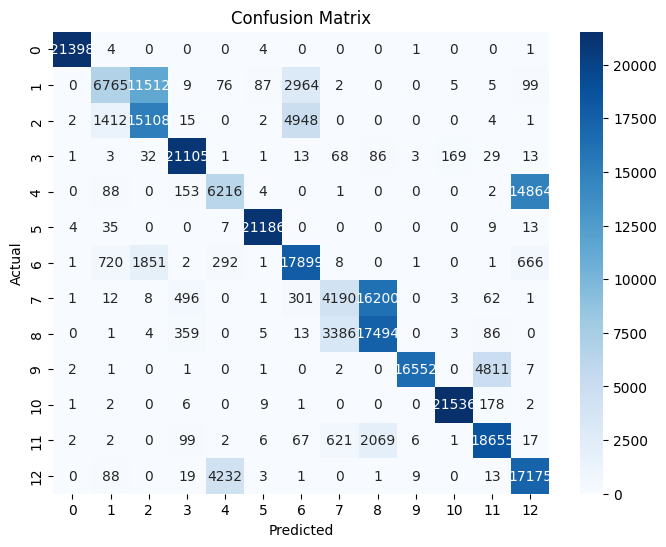

In [39]:
vconmat = confusion_matrix(stats['val_labels'][-1],stats['val_pred'][-1])
plt.figure(figsize=(8, 6))
sns.heatmap(vconmat, annot=True, cmap='Blues', fmt='d', 
            xticklabels=np.unique(stats['val_labels'][-1]), yticklabels=np.unique(stats['val_labels'][-1]))
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()